<a href="https://colab.research.google.com/github/thorbeorn/EPSI-M1-DataManagement-Etude-de-cas/blob/master/ProjetEtudeDeCas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:

import pandas as pd
import re   # pour les regex (emails)

# Chargement du fichier
df = pd.read_csv("/content/employees_raw.csv")

# Aperçu rapide
df.head()


,id,nom,prenom,sexe,date_naissance,categorie_pro,email,salaire_brut,date_embauche,secu_sociale
0,1000,Colas,Antoine,M,1999-12-24,Alternant,antoine.colas@barbier.org,23090,2024-05-14 00:00:00,158046912327970
1,1001,Barbier,Laurent,M,1963-11-10,Technicien,laurent.barbier@lesage.fr,43062,2019-01-03 00:00:00,00000000
2,1002,Lebreton,Simone,F,1986-02-02,Cadre,simone.lebreton,53508,2018-05-12 00:00:00,272043930000654
3,1003,Chauveau,André,M,1978-05-21,Ouvrier,andré.chauveau@michel.com,23665,2024-04-24 00:00:00,237055626001592
4,1004,Perez,Hélène,F,1996-05-29,Alternant,hélène.perez@didier.org,17588,2020-02-18 00:00:00,149070240802091


In [17]:
# Dimensions du dataset
print("Shape (lignes, colonnes) :", df.shape)

# Liste des colonnes
print("\nColonnes :")
print(df.columns)

# Types de données
print("\nTypes des colonnes :")
print(df.dtypes)

# Valeurs manquantes
print("\nValeurs manquantes par colonne :")
print(df.isna().sum())


Shape (lignes, colonnes) : (15000, 10)

Colonnes :
Index(['id', 'nom', 'prenom', 'sexe', 'date_naissance', 'categorie_pro',
       'email', 'salaire_brut', 'date_embauche', 'secu_sociale'],
      dtype='object')

Types des colonnes :
id                 int64
nom               object
prenom            object
sexe              object
date_naissance    object
categorie_pro     object
email             object
salaire_brut      object
date_embauche     object
secu_sociale      object
dtype: object

Valeurs manquantes par colonne :
id                  0
nom                 0
prenom              0
sexe                0
date_naissance      0
categorie_pro       0
email             360
salaire_brut        0
date_embauche     345
secu_sociale      449
dtype: int64


In [18]:
import re

# Regex basique pour valider un email
email_regex = r'^[\w\.-]+@[\w\.-]+\.\w+$'

def is_valid_email(email):
    email = str(email).strip()
    return bool(re.match(email_regex, email))

# Création de la colonne email_valid
df["email_valid"] = df["email"].apply(is_valid_email)

# Comptage des invalides
invalid_emails_count = (~df["email_valid"]).sum()

print("Emails invalides détectés :", invalid_emails_count)


Emails invalides détectés : 1255


In [19]:
# KPI
nb_emails_invalides = (~df["email_valid"]).sum()

# On supprime les emails invalides
df = df[df["email_valid"] == True].copy()

# On peut retirer la colonne technique
df.drop(columns=["email_valid"], inplace=True)

print("Nouvelles dimensions :", df.shape)
print("Emails invalides supprimés :", nb_emails_invalides)


Nouvelles dimensions : (13745, 10)
Emails invalides supprimés : 1255


In [20]:
# Vérifier quelques valeurs brutes
print("Exemples avant nettoyage :")
print(df["salaire_brut"].head(10))

# Nettoyage de la colonne salaire_brut
df["salaire_brut"] = (
    df["salaire_brut"]
    .astype(str)                      # tout en string
    .str.replace("€", "", regex=False)
    .str.replace("EUR", "", regex=False)
    .str.replace(" ", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace(".", "", regex=False)  # Pour les formats 45.000
)

# Conversion finale en entier
df["salaire_brut"] = df["salaire_brut"].astype(int)

print("\nExemples après nettoyage :")
print(df["salaire_brut"].head(10))

print("\nType de salaire_brut :", df["salaire_brut"].dtype)


Exemples avant nettoyage :
0      23090
1      43062
3      23665
4      17588
6     -22665
7      22870
8      32276
9      27742
11     22606
12     27082
Name: salaire_brut, dtype: object

Exemples après nettoyage :
0     23090
1     43062
3     23665
4     17588
6    -22665
7     22870
8     32276
9     27742
11    22606
12    27082
Name: salaire_brut, dtype: int64

Type de salaire_brut : int64


In [21]:
# Compter les salaires négatifs ou nuls
salaires_negatifs = df[df["salaire_brut"] <= 0].shape[0]
print("Salaires invalides (<= 0) :", salaires_negatifs)

# Supprimer les valeurs non plausibles
df = df[df["salaire_brut"] > 0].copy()

print("Nouvelles dimensions après suppression des salaires invalides :", df.shape)


Salaires invalides (<= 0) : 292
Nouvelles dimensions après suppression des salaires invalides : (13453, 10)


In [22]:
# Conversion en datetime
df["date_embauche"] = pd.to_datetime(df["date_embauche"], errors="coerce", dayfirst=True)

# Compter les dates invalides
nb_dates_invalides = df["date_embauche"].isna().sum()
print("Nombre de dates invalides détectées :", nb_dates_invalides)

# Supprimer les dates invalides
df = df[df["date_embauche"].notna()].copy()

# Format ISO (YYYY-MM-DD)
df["date_embauche"] = df["date_embauche"].dt.strftime("%Y-%m-%d")

# Vérification
print("\nExemples après nettoyage :")
print(df["date_embauche"].head())


Nombre de dates invalides détectées : 1308

Exemples après nettoyage :
0    2024-05-14
1    2019-01-03
3    2024-04-24
4    2020-02-18
7    2023-06-15
Name: date_embauche, dtype: object


/tmp/ipython-input-1867320359.py:2: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["date_embauche"] = pd.to_datetime(df["date_embauche"], errors="coerce", dayfirst=True)


In [23]:
import hashlib

def make_hash_id(row):
    key = f"{row['nom']}_{row['prenom']}_{row['date_naissance']}"
    return hashlib.sha256(key.encode()).hexdigest()[:16]

df["Hash_ID"] = df.apply(make_hash_id, axis=1)

# On supprime nom + prenom (données personnelles directes)
df.drop(columns=["nom", "prenom"], inplace=True)

df[["Hash_ID"]].head()


,Hash_ID
0,3c8400f931e88770
1,1fb5d17af9699b7a
3,f672c40f34ccb1fb
4,ca0b91ab833edac9
7,f8ceb30e57f82eaf


In [24]:
# On regarde quelques valeurs brutes
print("Avant masquage :")
print(df["secu_sociale"].head(10))

def mask_ssn(value):
    if pd.isna(value):
        return None
    s = str(value).strip()
    if len(s) <= 2:
        return "*" * len(s)
    return "*" * (len(s) - 2) + s[-2:]

df["secu_sociale_masked"] = df["secu_sociale"].apply(mask_ssn)

print("\nAprès masquage :")
print(df[["secu_sociale", "secu_sociale_masked"]].head(10))


Avant masquage :
0     158046912327970
1            00000000
3     237055626001592
4     149070240802091
7     235098400787916
8                 NaN
9     247016748207290
11    107078708544697
12    291129300846085
13    113039122851030
Name: secu_sociale, dtype: object

Après masquage :
       secu_sociale secu_sociale_masked
0   158046912327970     *************70
1          00000000            ******00
3   237055626001592     *************92
4   149070240802091     *************91
7   235098400787916     *************16
8               NaN                None
9   247016748207290     *************90
11  107078708544697     *************97
12  291129300846085     *************85
13  113039122851030     *************30


In [25]:
def view_dataset(role: str) -> pd.DataFrame:
    df_view = df.copy()

    if role == "Admin":
        # Admin voit tout, y compris secu_sociale brute
        return df_view

    elif role == "Manager":
        # Suppression de la colonne brute trop sensible
        if "secu_sociale" in df_view.columns:
            df_view = df_view.drop(columns=["secu_sociale"])

        # Arrondir les salaires au millier près
        df_view["salaire_brut"] = df_view["salaire_brut"].apply(lambda x: round(x, -3))

        return df_view

    else:
        raise ValueError("Role inconnu. Utiliser 'Admin' ou 'Manager'.")


In [26]:
print("Vue Admin :")
display(view_dataset("Admin").head())

print("\nVue Manager :")
display(view_dataset("Manager").head())


Vue Admin :


,id,sexe,date_naissance,categorie_pro,email,salaire_brut,date_embauche,secu_sociale,Hash_ID,secu_sociale_masked
0,1000,M,1999-12-24,Alternant,antoine.colas@barbier.org,23090,2024-05-14,158046912327970,3c8400f931e88770,*************70
1,1001,M,1963-11-10,Technicien,laurent.barbier@lesage.fr,43062,2019-01-03,00000000,1fb5d17af9699b7a,******00
3,1003,M,1978-05-21,Ouvrier,andré.chauveau@michel.com,23665,2024-04-24,237055626001592,f672c40f34ccb1fb,*************92
4,1004,F,1996-05-29,Alternant,hélène.perez@didier.org,17588,2020-02-18,149070240802091,ca0b91ab833edac9,*************91
7,1007,F,2001-04-26,Alternant,michelle.carlier@meunier.fr,22870,2023-06-15,235098400787916,f8ceb30e57f82eaf,*************16



Vue Manager :


,id,sexe,date_naissance,categorie_pro,email,salaire_brut,date_embauche,Hash_ID,secu_sociale_masked
0,1000,M,1999-12-24,Alternant,antoine.colas@barbier.org,23000,2024-05-14,3c8400f931e88770,*************70
1,1001,M,1963-11-10,Technicien,laurent.barbier@lesage.fr,43000,2019-01-03,1fb5d17af9699b7a,******00
3,1003,M,1978-05-21,Ouvrier,andré.chauveau@michel.com,24000,2024-04-24,f672c40f34ccb1fb,*************92
4,1004,F,1996-05-29,Alternant,hélène.perez@didier.org,18000,2020-02-18,ca0b91ab833edac9,*************91
7,1007,F,2001-04-26,Alternant,michelle.carlier@meunier.fr,23000,2023-06-15,f8ceb30e57f82eaf,*************16


## Métadonnées du dataset Gold

```yaml
dataset: employees_gold
owner: Direction_RH
description: >
  Dataset final nettoyé, anonymisé et gouverné dans le cadre du projet
  People Analytics, conforme aux exigences RGPD et aux bonnes pratiques
  de Data Management.

columns:

  - name: Hash_ID
    description: Identifiant pseudonymisé unique dérivé du nom, prénom et date de naissance.
    type: string
    sensitivity: Pseudonymized
    owner: Data Team

  - name: sexe
    description: Sexe déclaré de l’employé.
    type: categorical
    sensitivity: PII
    owner: RH

  - name: date_naissance
    description: Date de naissance de l’employé.
    type: date
    sensitivity: Highly Sensitive (PII)
    owner: RH

  - name: categorie_pro
    description: Catégorie socioprofessionnelle (cadre, employé, technicien, etc.).
    type: string
    sensitivity: Public
    owner: RH

  - name: email
    description: Adresse email professionnelle, nettoyée et validée via regex.
    type: string
    sensitivity: PII
    owner: RH

  - name: salaire_brut
    description: >
      Salaire annuel brut en euros, converti depuis un format textuel hétérogène
      vers un entier. Utilisé pour les analyses de parité salariale.
    type: integer
    sensitivity: Confidentiel
    owner: Finance

  - name: date_embauche
    description: Date d’entrée de l’employé dans l’entreprise (format ISO YYYY-MM-DD).
    type: date
    sensitivity: Public
    owner: RH

  - name: secu_sociale
    description: Numéro de sécurité sociale complet (réservé au rôle Admin).
    type: string
    sensitivity: Highly Sensitive (Secret)
    owner: Compliance

  - name: secu_sociale_masked
    description: Version masquée de la sécurité sociale (garde uniquement les 2 derniers chiffres).
    type: string
    sensitivity: Restricted
    owner: Compliance

```


In [28]:
import datetime as dt

today = dt.date.today()

df["date_naissance"] = pd.to_datetime(df["date_naissance"], errors="coerce")

# Calcul de l'âge
df["age"] = df["date_naissance"].apply(
    lambda d: today.year - d.year - ((today.month, today.day) < (d.month, d.day))
)

df[["date_naissance", "age"]].head()


,date_naissance,age
0,1999-12-24,25
1,1963-11-10,62
3,1978-05-21,47
4,1996-05-29,29
7,2001-04-26,24


from matplotlib import pyplot as plt
_df_1['age'].plot(kind='hist', bins=20, title='age')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['date_naissance']
  ys = series['age']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_2.sort_values('date_naissance', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('date_naissance')
_ = plt.ylabel('age')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['date_naissance']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'date_naissance'}, axis=1)
              .sort_values('date_naissance', ascending=True))
  xs = counted['date_naissance']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_3.sort_values('date_naissance', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('date_naissance')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['date_naissance']
  ys = series['age']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_4.sort_values('date_naissance', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('date_naissance')
_ = plt.ylabel('age')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['date_naissance']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'date_naissance'}, axis=1)
              .sort_values('date_naissance', ascending=True))
  xs = counted['date_naissance']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_5.sort_values('date_naissance', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('date_naissance')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_6['age'].plot(kind='line', figsize=(8, 4), title='age')
plt.gca().spines[['top', 'right']].set_visible(False)

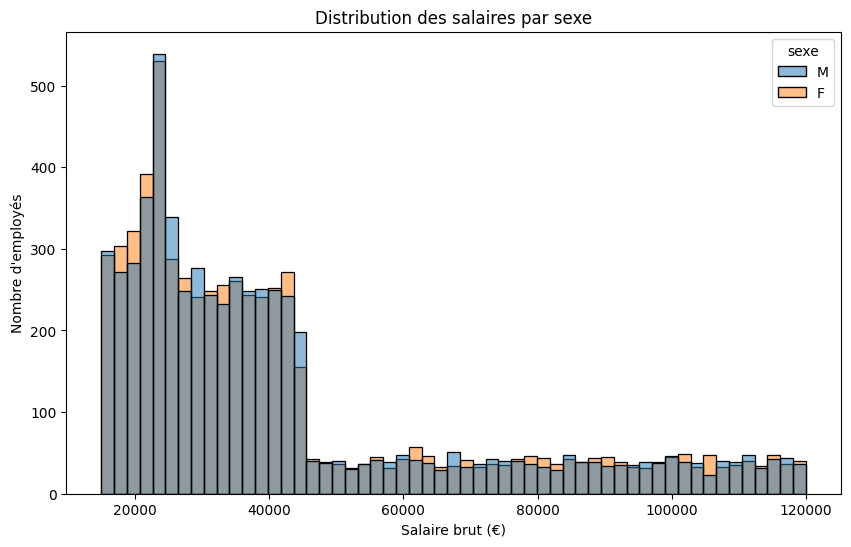

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.histplot(data=df, x="salaire_brut", hue="sexe", kde=False)
plt.title("Distribution des salaires par sexe")
plt.xlabel("Salaire brut (€)")
plt.ylabel("Nombre d'employés")
plt.show()


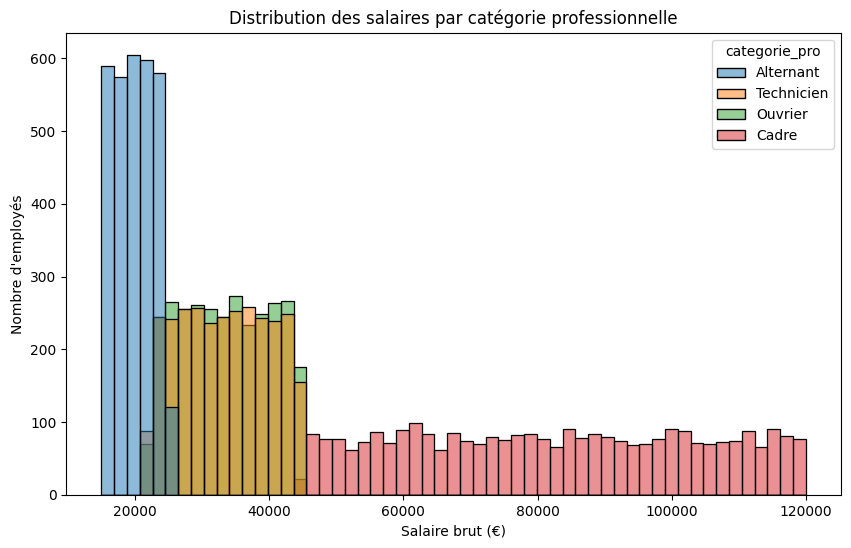

In [30]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="salaire_brut", hue="categorie_pro", kde=False)
plt.title("Distribution des salaires par catégorie professionnelle")
plt.xlabel("Salaire brut (€)")
plt.ylabel("Nombre d'employés")
plt.show()


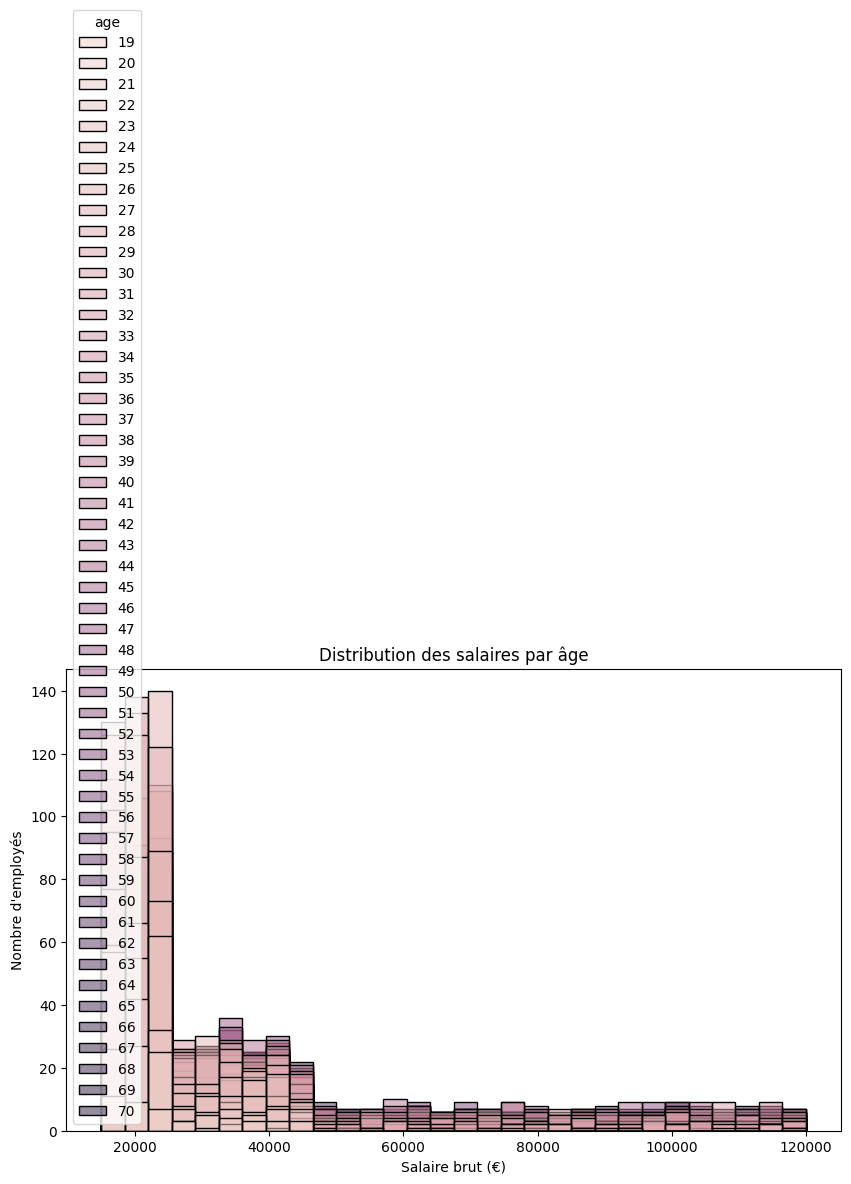

In [31]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="salaire_brut", hue="age", kde=False, bins=30)
plt.title("Distribution des salaires par âge")
plt.xlabel("Salaire brut (€)")
plt.ylabel("Nombre d'employés")
plt.show()


In [33]:
print("----- KPI -----")
print("Salaire moyen global :", df["salaire_brut"].mean())

print("Emails invalides supprimés :", nb_emails_invalides)
print("Dates invalides supprimées :", nb_dates_invalides)
print("Salaires négatifs supprimés :", salaires_negatifs)


----- KPI -----
Salaire moyen global : 42406.99703581721
Emails invalides supprimés : 1255
Dates invalides supprimées : 1308
Salaires négatifs supprimés : 292


/tmp/ipython-input-2351425371.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="sexe", y="salaire_brut", palette="Set2")


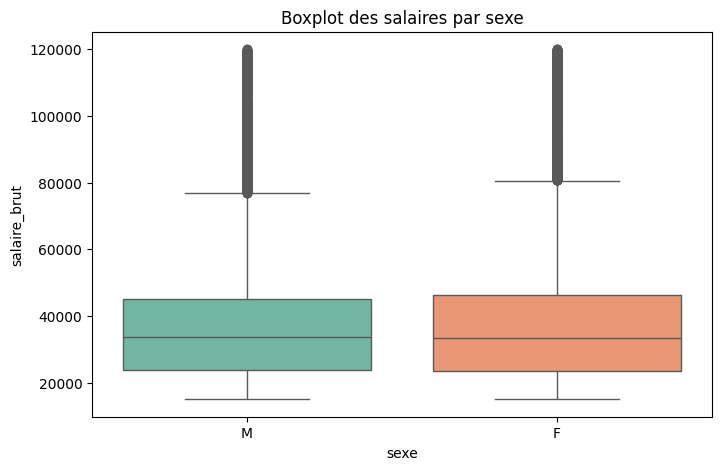

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="sexe", y="salaire_brut", palette="Set2")
plt.title("Boxplot des salaires par sexe")
plt.show()
